# Supervised Learning

In supervised learning, you give the algorithm data ($X$) and the answers ($y$). The model learns the mapping from $X \rightarrow y$ so it can predict $y$ for unseen data.

There are two main types of supervised learning:
1.  **Regression:** Predicting a continuous number (e.g., house price, temperature).
2.  **Classification:** Predicting a category (e.g., spam/not spam, dog/cat/bird).

## 1. Linear Regression

The simplest model. It draws a line (or hyperplane in higher dimensions) through the data that minimizes the Mean Squared Error (MSE) between the line and the actual data points.

Intercept (b): 4.22
Weight (w): 2.77


Text(0, 0.5, 'Price')

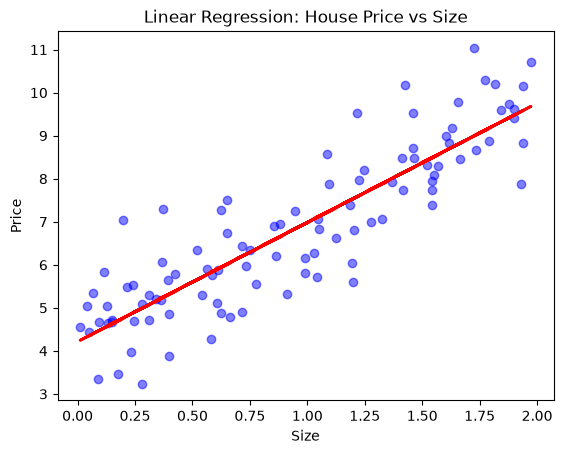

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Generate fake data: House size vs Price
np.random.seed(42)
X = 2 * np.random.rand(100, 1)        # House sizes (sq ft / 1000)
y = 4 + 3 * X + np.random.randn(100, 1) # Price = 4 + 3*Size + Noise

# Train the model
model = LinearRegression()
model.fit(X, y)

print(f"Intercept (b): {model.intercept_[0]:.2f}")
print(f"Weight (w): {model.coef_[0][0]:.2f}")

# Plotting the regression line
plt.scatter(X, y, color='blue', alpha=0.5)
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.title("Linear Regression: House Price vs Size")
plt.xlabel("Size")
plt.ylabel("Price")
# plt.show()

## 2. Logistic Regression (Classification)

Despite the name, Logistic Regression is used for *classification*. It passes a linear regression output through a Sigmoid function, squishing the output between 0 and 1 (acting as a probability).

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# Generate a binary classification dataset
X_class, y_class = make_classification(n_samples=100, n_features=2, 
                                       n_informative=2, n_redundant=0, 
                                       random_state=42)

clf = LogisticRegression()
clf.fit(X_class, y_class)

# Predict probabilities for the first 3 samples
probs = clf.predict_proba(X_class[:3])
print("Probabilities (Class 0, Class 1):")
print(np.round(probs, 3))

Probabilities (Class 0, Class 1):
[[0.54  0.46 ]
 [0.007 0.993]
 [0.966 0.034]]


## 3. Decision Trees & Random Forests

Linear models fail when the relationship in the data is non-linear. **Decision Trees** split the data based on questions (e.g., "Is age > 30?").

A **Random Forest** is an *ensemble* of many decision trees. By training 100 different trees on slightly different subsets of the data and averaging their predictions, we drastically reduce overfitting.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Using the same classification dataset from above
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)

preds = rf_model.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, preds) * 100}%")

# Random Forests give us Feature Importance for free!
print("Feature Importances:", rf_model.feature_importances_)

Random Forest Accuracy: 100.0%
Feature Importances: [0.78534895 0.21465105]


## 4. Gradient Boosting (XGBoost)

For tabular (CSV) data, Gradient Boosted Trees (like XGBoost or LightGBM) are the undisputed kings. Instead of building independent trees like a Random Forest, Gradient Boosting builds trees *sequentially*. Each new tree tries to correct the errors made by the previous trees.

In [6]:
# Note: You need to install xgboost: pip install xgboost
import xgboost as xgb

# XGBoost has a similar scikit-learn API wrapper
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds) * 100}%")
print(xgb_preds)

XGBoost Accuracy: 100.0%
[1 0 0 0 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 1]


---
## References
*   [Scikit-Learn: Linear Models](https://scikit-learn.org/stable/modules/linear_model.html)
*   [XGBoost Documentation](https://xgboost.readthedocs.io/)